### KNN Hyperparameter
- Build a K-Nearest Neighbors classifier and experiment with how the choice of $K$ and distance metrics alters the complexity of the model. The Data: The Wine Quality Dataset (available on Kaggle or via sklearn.datasets.load_wine). Core Topics to Cover:Load the dataset and separate the features from the target (wine class).Implement feature scaling.Write a loop that trains a KNN model for every value of $K$ from 1 to 20.For each $K$, record the training accuracy and the validation accuracy using 5-fold Cross-Validation.Plot the results on a line graph (a Learning Curve) to visually identify the Bias-Variance tradeoff. Find the "sweet spot" for $K$.Re-run the best model, but change the distance metric from L2 (Euclidean) to L1 (Manhattan) and note any differences.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

### Load the dataset

In [11]:
wine = load_wine()

X = wine.data
y = wine.target

print(X.shape)
print(np.unique(y))

(178, 13)
[0 1 2]


### Feature Scalling
- KNN depends heavily on distance, so scaling matters.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train K from 1 to 20
We record:
- training accuracy
- cross-validation accuracy

In [13]:
k_values = range(1, 21)

train_scores = []
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # training accuracy
    knn.fit(X_scaled, y)
    train_acc = knn.score(X_scaled, y)

    # 5-fold CV
    cv_acc = cross_val_score(
        knn,
        X_scaled,
        y,
        cv=5
    ).mean()

    train_scores.append(train_acc)
    cv_scores.append(cv_acc)

### Plot learning curve

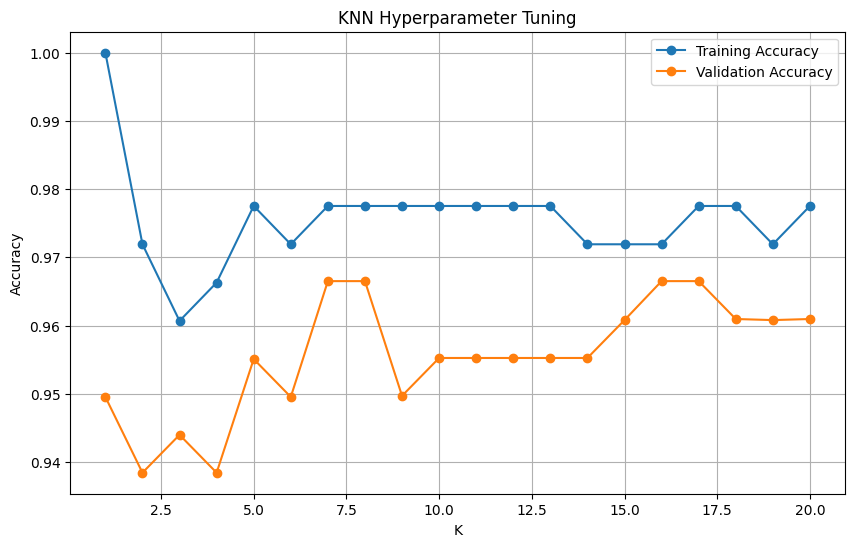

In [18]:
plt.figure(figsize=(10,6))
plt.plot(k_values, train_scores, marker='o', label="Training Accuracy")
plt.plot(k_values, cv_scores, marker='o', label="Validation Accuracy")

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparameter Tuning")
plt.legend()
plt.grid(True)
plt.show()

### Interprettation
Usually:

small K
low bias
high variance
overfitting
training ≈ 100%
large K
higher bias
smoother boundary
underfitting

Sweet spot:
highest validation accuracy

### Find best K

In [19]:
best_k = k_values[np.argmax(cv_scores)]
best_score = np.max(cv_scores)

print("Best K:", best_k)
print("Best CV Accuracy:", best_score)

Best K: 7
Best CV Accuracy: 0.9665079365079364


### Compare distance metrics

- Default = Euclidean (L2)

- Now compare Manhattan (L1)

In [16]:
knn_l2 = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
knn_l1 = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=1)

score_l2 = cross_val_score(knn_l2, X_scaled, y, cv=5).mean()
score_l1 = cross_val_score(knn_l1, X_scaled, y, cv=5).mean()

print("Euclidean (L2):", score_l2)
print("Manhattan (L1):", score_l1)

Euclidean (L2): 0.9665079365079364
Manhattan (L1): 0.9607936507936508


### Visual comparison

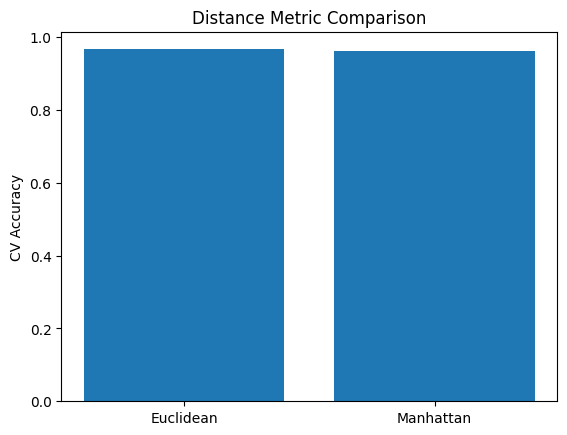

In [17]:
metrics = ["Euclidean", "Manhattan"]
scores = [score_l2, score_l1]

plt.figure()
plt.bar(metrics, scores)
plt.ylabel("CV Accuracy")
plt.title("Distance Metric Comparison")
plt.show()